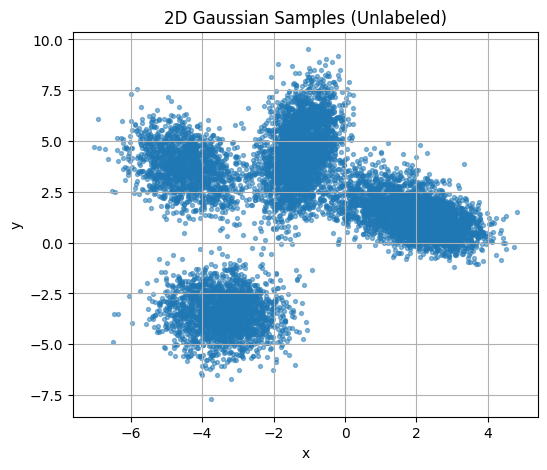

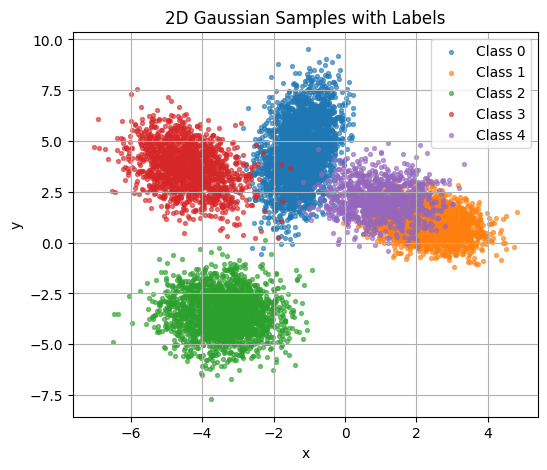

(5, 2, 2)


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------
np.random.seed(42)

# ------------------------------------------------
# Parameters
# ------------------------------------------------
N = 10000
num_classes = 5

# Unequal class weights (sum to 1)
weights = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

# ------------------------------------------------
# Generate reasonable means automatically
# ------------------------------------------------
# Means are spread in a bounded 2D region
means = np.random.uniform(-5, 5, size=(num_classes, 2))

# ------------------------------------------------
# Generate reasonable covariance matrices
# ------------------------------------------------
covariances = []

for _ in range(num_classes):
    # random standard deviations
    sx, sy = np.random.uniform(0.5, 1.5, size=2)

    # small correlation
    rho = np.random.uniform(-0.5, 0.5)

    cov = np.array([
        [sx**2, rho * sx * sy],
        [rho * sx * sy, sy**2]
    ])

    covariances.append(cov)

# ------------------------------------------------
# Generate data
# ------------------------------------------------
X = []
y = []

for k in range(num_classes):
    Nk = int(weights[k] * N)
    samples = np.random.multivariate_normal(
        mean=means[k],
        cov=covariances[k],
        size=Nk
    )
    labels = np.full(Nk, k)

    X.append(samples)
    y.append(labels)

X = np.vstack(X)
y = np.concatenate(y)

# ------------------------------------------------
# Plot 1: Samples WITHOUT labels
# ------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gaussian Samples (Unlabeled)")
plt.grid(True)
plt.show()

# ------------------------------------------------
# Plot 2: Samples WITH labels
# ------------------------------------------------
plt.figure(figsize=(6, 5))

for k in range(num_classes):
    plt.scatter(
        X[y == k, 0],
        X[y == k, 1],
        s=8,
        label=f"Class {k}",
        alpha=0.6
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gaussian Samples with Labels")
plt.legend()
plt.grid(True)
plt.show()
covariances = np.array(covariances)
print(covariances.shape)


In [17]:
# ================================================================
# EM ALGORITHM FROM SCRATCH (Gaussian Mixture Model)
# ================================================================

K = 4              # WRONG number of latent classes
N, D = X.shape
max_iters = 50
eps = 1e-6

# ------------------------------------------------
# Initialization
# ------------------------------------------------
np.random.seed(0)

# Initialize means randomly from data
indices = np.random.choice(N, K, replace=False)
mu = X[indices]

# Initialize covariances as identity matrices
Sigma = np.array([np.eye(D) for _ in range(K)])

# Initialize mixture weights uniformly
pi = np.ones(K) / K

# ------------------------------------------------
# Gaussian PDF
# ------------------------------------------------
def gaussian_pdf(x, mean, cov):
    diff = x - mean
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    norm = 1.0 / np.sqrt((2 * np.pi)**D * det)
    return norm * np.exp(-0.5 * diff @ inv @ diff)

# ------------------------------------------------
# EM iterations
# ------------------------------------------------
log_likelihoods = []

for iteration in range(max_iters):

    # ======================
    # E-step
    # ======================
    gamma = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            gamma[n, k] = pi[k] * gaussian_pdf(X[n], mu[k], Sigma[k])

        # Normalize responsibilities
        gamma[n] /= np.sum(gamma[n])

    # ======================
    # M-step
    # ======================
    Nk = np.sum(gamma, axis=0)

    for k in range(K):
        # Update mean
        mu[k] = np.sum(gamma[:, k, None] * X, axis=0) / Nk[k]

        # Update covariance
        diff = X - mu[k]
        Sigma[k] = (
            (gamma[:, k, None, None] *
             np.einsum('ni,nj->nij', diff, diff)).sum(axis=0)
            / Nk[k]
        )

        # Regularization for numerical stability
        Sigma[k] += eps * np.eye(D)

        # Update weight
        pi[k] = Nk[k] / N

    # ======================
    # Log-likelihood
    # ======================
    ll = 0
    for n in range(N):
        tmp = 0
        for k in range(K):
            tmp += pi[k] * gaussian_pdf(X[n], mu[k], Sigma[k])
        ll += np.log(tmp)

    log_likelihoods.append(ll)

    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < 1e-3:
        print(f"Converged at iteration {iteration}")
        break


Converged at iteration 42


Shape of Sigma after EM: (4, 2, 2)
Covariance matrices after EM:
Cluster 0 covariance (2x2):
[[ 0.88486428 -0.40865255]
 [-0.40865255  0.79476145]]

Cluster 1 covariance (2x2):
[[ 0.60217251 -0.28089302]
 [-0.28089302  1.20856236]]

Cluster 2 covariance (2x2):
[[0.27004241 0.24966001]
 [0.24966001 2.25714255]]

Cluster 3 covariance (2x2):
[[ 0.67278729 -0.04464828]
 [-0.04464828  1.05039496]]



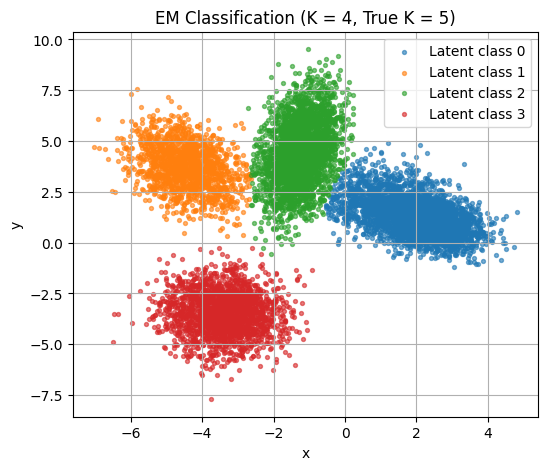

In [18]:
# ================================================================
# Classification using EM (MAP estimate)
# ================================================================
print("Shape of Sigma after EM:", Sigma.shape)
print("Covariance matrices after EM:")

for k in range(K):
    print(f"Cluster {k} covariance (2x2):\n{Sigma[k]}\n")
    
y_em = np.argmax(gamma, axis=1)

plt.figure(figsize=(6, 5))

for k in range(K):
    plt.scatter(
        X[y_em == k, 0],
        X[y_em == k, 1],
        s=8,
        label=f"Latent class {k}",
        alpha=0.6
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("EM Classification (K = 4, True K = 5)")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_em)
print("Confusion matrix (true vs EM labels):")
print(cm)


Confusion matrix (true vs EM labels):
[[   7    7 2984    2    0]
 [2500    0    0    0    0]
 [   0    0    2 1998    0]
 [   0 1479   21    0    0]
 [ 964    0   36    0    0]]


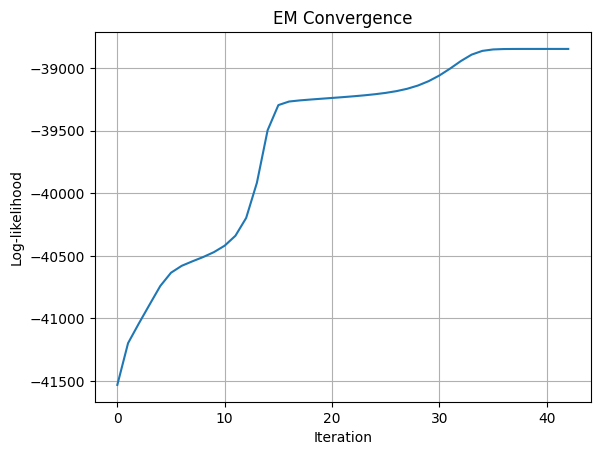

In [20]:
plt.figure()
plt.plot(log_likelihoods)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("EM Convergence")
plt.grid(True)
plt.show()


In [25]:
subset_size = 2000
indices = np.arange(N)
np.random.shuffle(indices)
subset_indices = indices[:subset_size]

X_sub = X[subset_indices]
y_sub = y[subset_indices]  # true labels for comparison

In [26]:
N_sub, D = X_sub.shape
K = 4  # deliberately wrong
max_iters = 50
eps = 1e-6

# Initialization
np.random.seed(0)
indices = np.random.choice(N_sub, K, replace=False)
mu = X_sub[indices]
Sigma = np.array([np.eye(D) for _ in range(K)])
pi = np.ones(K) / K

# Gaussian PDF
def gaussian_pdf(x, mean, cov):
    diff = x - mean
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    norm = 1.0 / np.sqrt((2 * np.pi)**D * det)
    return norm * np.exp(-0.5 * diff @ inv @ diff)

# EM iterations
log_likelihoods = []

for iteration in range(max_iters):
    # E-step
    gamma = np.zeros((N_sub, K))
    for n in range(N_sub):
        for k in range(K):
            gamma[n, k] = pi[k] * gaussian_pdf(X_sub[n], mu[k], Sigma[k])
        gamma[n] /= np.sum(gamma[n])

    # M-step
    Nk = np.sum(gamma, axis=0)
    for k in range(K):
        mu[k] = np.sum(gamma[:, k, None] * X_sub, axis=0) / Nk[k]
        diff = X_sub - mu[k]
        Sigma[k] = (
            (gamma[:, k, None, None] * np.einsum('ni,nj->nij', diff, diff)).sum(axis=0) / Nk[k]
        )
        Sigma[k] += eps * np.eye(D)
        pi[k] = Nk[k] / N_sub

    # Log-likelihood
    ll = 0
    for n in range(N_sub):
        tmp = 0
        for k in range(K):
            tmp += pi[k] * gaussian_pdf(X_sub[n], mu[k], Sigma[k])
        ll += np.log(tmp)
    log_likelihoods.append(ll)

    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < 1e-3:
        print(f"Converged at iteration {iteration}")
        break

Converged at iteration 18


In [27]:
y_em_sub = np.argmax(gamma, axis=1)
accuracy = np.mean(y_em_sub == y_sub)  # now shapes match
print("Test number (accuracy on subset):", accuracy)

# Or you can use log-likelihood
print("Test number (final log-likelihood):", log_likelihoods[-1])


Test number (accuracy on subset): 0.0005
Test number (final log-likelihood): -7756.856480655287
